In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
import pandas as pd

In [1]:
# Proejct : Shoppingmall Heatmap Analysis?? 
# Create 1000 human simulation
# Create Shops 
# Creaet Noise(Human)
# Apply DBSCAN
# Visualize 

In [30]:
# Data( morning, Night) 
morning_rush = np.random.normal(loc=[2,2], scale = 0.5, size=(500,2))
morning_data = np.column_stack((morning_rush, [10]*500))  # 10 Am 

noon_rush = np.random.normal(loc=[2,2], scale = 0.5, size=(500,2))
noon_data = np.column_stack((morning_rush, [10]*500))  # 10 Am 

evening_rush = np.random.normal(loc=[8,8], scale = 0.5, size=(500,2))
evening_data = np.column_stack((evening_rush, [20]*500))  # 8 pm 

In [31]:
df = pd.DataFrame(np.vstack([morning_data, evening_data]), columns=['X','Y', 'Hour'])

In [34]:
# Analysis Function
def analyze_mall_rush(hour):
    subset = df[df['Hour'] == hour]
    X_coords = subset[['X', 'Y']]

    # DBSCAN 
    db = DBSCAN(eps=0.6, min_samples=10).fit(X_coords)

    # Visulalize
    plt.scatter(X_coords.iloc[:, 0], X_coords.iloc[:,1], c=db.labels_, cmap='viridis')
    plt.title(f"Customer Analysis at {hour}:00")
    plt.xlim(0,10);plt.ylim(0,10)
    plt.show()

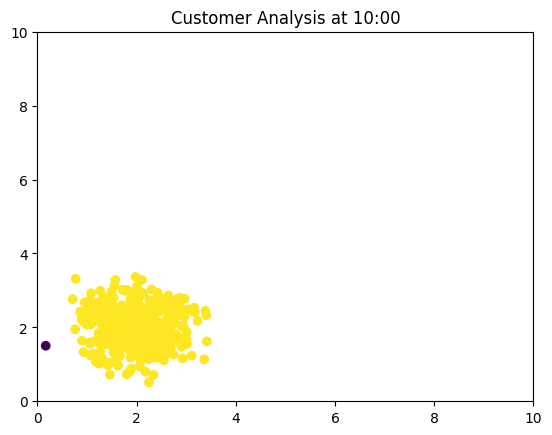

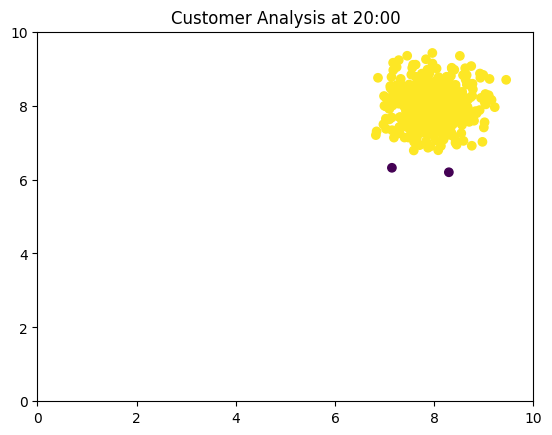

In [35]:
# Check 
analyze_mall_rush(10) # Morning 10 AM
analyze_mall_rush(20) # Eneving 8 PM

In [ ]:
# Enhancing: Dwell Time Analysis 

In [44]:
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [45]:
# Setting for reproducibility
np.random.seed(42)

In [46]:
# Generate Mall Data
def generate_mall_data():
    # Area 1 : Food Court(Dense, high dwell times) 
    food_court = np.random.normal(loc=[2, 2], scale=0.6, size=(200,2))
    dwell_food = np.random.normal(loc=45, scale = 10, size=(200,1)) # 45 mins 

    # Area 2: Anchor Shop(Large area, medium density)
    anchor_store = np.random.normal(loc=[7, 3], scale=1.2, size=(150,2))
    dwell_anchor = np.random.normal(loc=30, scale = 5, size=(150,1)) # 30 mins 

    # Area 3: Entrance/Corridor(Noise - people moving, low density) 
    corridor = np.random.uniform(low=0, high=10, size=(50,2))
    dwell_corridor = np.random.uniform(low=1, high=5, size=(50,1))  # 5 mins

    data = np.vstack([
        np.hstack([food_court, dwell_food]),
        np.hstack([anchor_store,dwell_anchor]),
        np.hstack([corridor,dwell_corridor])      
    ])

    return pd.DataFrame(data, columns=['X', 'Y', 'Dwell_Time'])

df = generate_mall_data()

In [47]:
df.head

<bound method NDFrame.head of             X         Y  Dwell_Time
0    2.298028  1.917041   29.055723
1    2.388613  2.913818   39.006250
2    1.859508  1.859518   45.052437
3    2.947528  2.460461   45.469806
4    1.718315  2.325536   40.499345
..        ...       ...         ...
395  0.303871  9.309487    4.059533
396  6.895268  6.765134    4.251943
397  2.156752  6.588855    3.872492
398  3.938644  6.512330    4.822095
399  1.065930  6.578453    1.072930

[400 rows x 3 columns]>

In [49]:
def business_cluster_analysis(data):
    # 1. Feature Scaling (when units differ)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(data)

    # 2. Fit DBSCAN 
    db = DBSCAN(eps=0.5, min_samples=10).fit(X_scaled)
    data['Cluster']=db.labels_ 

    # 3. Business Metrics Calculation
    # -1 represents 'Noise' in DBSCAN 
    stats = data[data['Cluster'] != -1].groupby('Cluster').agg({
        'Dwell_Time':['mean','count'],
        'X': 'mean',
        'Y': 'mean'
    }).reset_index()

    return data, stats

clustered_df, cluster_stats = business_cluster_analysis(df)

C:\Users\Asus\AppData\Local\Temp\ipykernel_15400\3366360211.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_stats['Cluster'], y=cluster_stats['Dwell_Time'] ['mean'], palette='magma')


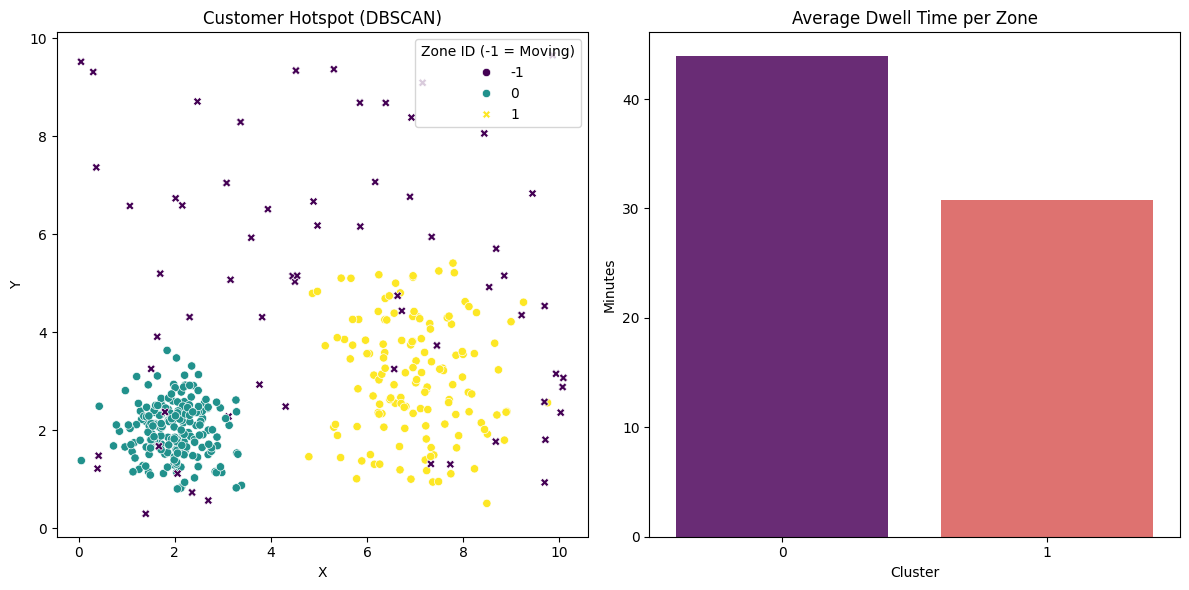

In [50]:
def plot_mall_dashboard(data, stats):
    plt.figure(figsize=(12,6))

    # plot 1: Spatial Cluster
    plt.subplot(1,2,1)
    sns.scatterplot(data=data, x='X', y='Y', hue='Cluster', palette='viridis', style=(data['Cluster']==-1))
    plt.title("Customer Hotspot (DBSCAN)")
    plt.legend(title="Zone ID (-1 = Moving)")

    # plot 2: Business Value (Dwell Time vs Density)
    plt.subplot(1,2,2)
    sns.barplot(x=cluster_stats['Cluster'], y=cluster_stats['Dwell_Time'] ['mean'], palette='magma')
    plt.title("Average Dwell Time per Zone")
    plt.ylabel('Minutes')

    plt.tight_layout()
    plt.show()


plot_mall_dashboard(clustered_df, cluster_stats)
    

In [ ]:
# Home Work: Purchase probability column based on how long they stay in a specific cluster. 